---
date: "2026-07-11"
date-modified: last-modified
format:
  html:
    toc: true
---
<!-- CELL BREAK -->

# Measure Spaces

## 1\. Motivation for Measure Theory

The historical drive toward measure theory and the Lebesgue integral stemmed from the limitations of the Riemann integral. Key issues with the Riemann framework include:

1.  **Limits of Functions:** The point-wise limit of a sequence of continuous functions is not necessarily continuous. More problematically, the limit of a sequence of Riemann-integrable functions $f_n \to f$ is not necessarily Riemann-integrable. We need a more robust space of functions that is "closed" under taking limits.
2.  **Geometric Pathologies:** Can we define a universal "measure" (generalizing length, area, and volume) on *all* subsets of $\mathbb{R}^n$ that behaves exactly like standard Euclidean volume? The answer is no, famously demonstrated by the [Banach-Tarski paradox](https://en.wikipedia.org/wiki/Banach%E2%80%93Tarski_paradox). This paradox shows that it is possible to take a solid 3D sphere, partition it into a finite number of pieces ($E_1, \dots, E_n$), and reassemble them using only rigid rotations and translations to form *two* identical copies of the original sphere!

To resolve this, we must restrict the sets we are willing to measure to a [sigma-algebra](sigma-algebra.ipynb) and define a rigorous, abstract concept of a measure.

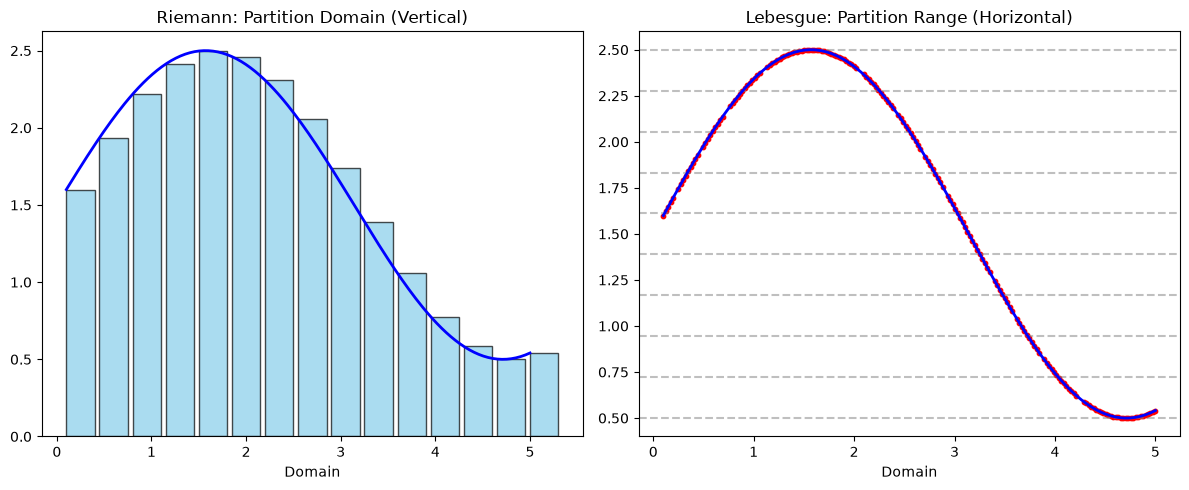

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualization of Riemann (Vertical) vs Lebesgue (Horizontal) intuition
x = np.linspace(0.1, 5, 200)
y = np.sin(x) + 1.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Riemann: Partition the domain (x-axis)
x_bars = np.linspace(0.1, 5, 15)
y_bars = np.sin(x_bars) + 1.5
ax1.bar(x_bars, y_bars, width=0.3, align='edge', color='skyblue', edgecolor='black', alpha=0.7)
ax1.plot(x, y, color='blue', linewidth=2)
ax1.set_title("Riemann: Partition Domain (Vertical)")
ax1.set_xlabel("Domain")

# Lebesgue: Partition the range (y-axis)
y_levels = np.linspace(0.5, 2.5, 10)
for level in y_levels:
    ax2.axhline(level, color='gray', linestyle='--', alpha=0.5)
    # Highlight points on curve close to the level
    mask = np.abs(y - level) < 0.1
    ax2.scatter(x[mask], y[mask], color='red', s=10)
    
ax2.plot(x, y, color='blue', linewidth=2)
ax2.set_title("Lebesgue: Partition Range (Horizontal)")
ax2.set_xlabel("Domain")

plt.tight_layout()
plt.show()



## 2. Measurable Spaces and Measures

We build a measure space in two structural steps. First, we pair a set with a [$\sigma$-algebra](sigma-algebra.ipynb). Second, we assign a measure to that structure.

**Definition:** A **measurable space** is a pair $(X, \mathcal{M})$ consisting of a set $X$ and a $\sigma$-algebra $\mathcal{M}$ of subsets of $X$. A subset $E \subseteq X$ is called **measurable** (with respect to $\mathcal{M}$) if $E \in \mathcal{M}$.

**Definition:** Let $(X, \mathcal{M})$ be a measurable space. A **measure** $\mu$ is an extended real-valued set function $\mu : \mathcal{M} \rightarrow [0, \infty]$ that satisfies the following properties:

1. **Non-negativity:** $\mu(E) \ge 0$ for all $E \in \mathcal{M}$.
2. **Measure of Empty Set:** $\mu(\emptyset) = 0$.
3. **Countable Additivity:** For any countable disjoint collection $\{E_k\}_{k=1}^\infty$ of measurable sets, the measure of their union is the sum of their measures:
$$\mu\left( \bigcup_{k=1}^\infty E_k \right) = \sum_{k=1}^\infty \mu(E_k)$$



A **measure space** is defined as the triplet $(X, \mathcal{M}, \mu)$.

::: {.callout-note}

## Note on Subspaces

If $(X, \mathcal{M}, \mu)$ is a measure space and we take a measurable subset $X_0 \in \mathcal{M}$, we can construct a new measure space $(X_0, \mathcal{M}_0, \mu_0)$ where $\mathcal{M}_0$ contains all sets in $\mathcal{M}$ that are subsets of $X_0$, and $\mu_0$ is simply the restriction of $\mu$.
:::

## 3. Common Examples of Measures

Several standard measures populate analysis and probability:

1. **Lebesgue Measure Space** $(\mathbb{R}, \mathcal{L}, m)$: $m$ is the standard Lebesgue measure extending the notion of "length" of intervals.
2. **Borel Measure Space** $(\mathbb{R}, \mathcal{B}, m)$: The same Lebesgue measure, but strictly restricted to the smaller [Borel sigma-algebra]().
3. **Counting Measure:** Defined on the measurable space $(X, 2^X)$. For any finite set $E$, $\mu(E) = |E|$ (the number of elements). If $E$ is infinite, $\mu(E) = \infty$.
4. **Dirac Measure:** For a specific point $x_0 \in X$, the Dirac measure $\delta_{x_0}$ assigns a measure of $1$ if $x_0 \in E$ and $0$ if $x_0 \notin E$. This forms the Dirac measure space $(X, \mathcal{M}, \delta_{x_0})$.
5. **Countable/Co-countable Measure:** Let $X$ be an uncountable set, and let $\mathcal{M}$ be the collection of all subsets that are either countable or whose complement is countable (co-countable). We define $\mu(E) = 0$ if $E$ is countable, and $\mu(E) = 1$ if $E^c$ is countable.

## 4. Fundamental Properties of Measures

A standard measure automatically enjoys several highly intuitive arithmetic properties.

**Proposition 1:** Let $(X, \mathcal{M}, \mu)$ be a measure space. The measure $\mu$ exhibits finite additivity, monotonicity, and excision.

::: {.callout-tip collapse="false"}

## Proof of Finite Additivity

**Statement:** For any finite disjoint collection $\{E_k\}_{k=1}^n$ of measurable sets, $\mu(\bigcup_{k=1}^n E_k) = \sum_{k=1}^n \mu(E_k)$.

**Proof:**
We know by definition that $\mu$ is countably additive. To prove finite additivity from countable additivity, we simply "pad" our finite sequence of sets with empty sets.
Let $E_{n+1} = \emptyset, E_{n+2} = \emptyset, \dots$
Because the empty set is disjoint from every set, the infinite sequence $\{E_k\}_{k=1}^\infty$ is still a disjoint collection.
Using countable additivity:

$$\begin{aligned}
\mu\left( \bigcup_{k=1}^n E_k \right) &= \mu\left( \bigcup_{k=1}^\infty E_k \right) \\
&= \sum_{k=1}^\infty \mu(E_k) \\
&= \sum_{k=1}^n \mu(E_k) + \sum_{k=n+1}^\infty \mu(\emptyset) \\
&= \sum_{k=1}^n \mu(E_k) + 0 \\
&= \sum_{k=1}^n \mu(E_k)
\end{aligned}$$

$\blacksquare$
:::

::: {.callout-tip collapse="false"}

## Proof of Monotonicity

**Statement:** If $A$ and $B$ are measurable sets and $A \subseteq B$, then $\mu(A) \le \mu(B)$.

**Proof:**
Since $A \subseteq B$, we can decompose $B$ into two disjoint measurable sets: $A$ and the relative complement $B \setminus A$.

$$B = A \cup (B \setminus A)$$

Because these sets are disjoint, we apply finite additivity:

$$\mu(B) = \mu(A) + \mu(B \setminus A)$$

By definition, measures are non-negative, so $\mu(B \setminus A) \ge 0$. Therefore:

$$\mu(B) \ge \mu(A)$$

$\blacksquare$
:::

::: {.callout-tip collapse="false"}

## Proof of Excision

**Statement:** If $A \subseteq B$ and $\mu(A) < \infty$, then $\mu(B \setminus A) = \mu(B) - \mu(A)$. Consequently, if $\mu(A) = 0$, then $\mu(B \setminus A) = \mu(B)$.

**Proof:**
From the proof of monotonicity, we established the decomposition:

$$\mu(B) = \mu(A) + \mu(B \setminus A)$$

Because we are explicitly given that $\mu(A) < \infty$, we are safely allowed to subtract $\mu(A)$ from both sides of the equation without running into indeterminate arithmetic (like $\infty - \infty$). Subtracting $\mu(A)$ yields:

$$\mu(B \setminus A) = \mu(B) - \mu(A)$$

If $\mu(A) = 0$, then clearly $\mu(B \setminus A) = \mu(B) - 0 = \mu(B)$. $\blacksquare$
:::

::: {.callout-warning}

## Warning on Excision

The condition that $\mu(A) < \infty$ in the Excision property is absolutely critical. If $\mu(A) = \infty$ and $\mu(B) = \infty$, the subtraction $\infty - \infty$ is mathematically undefined in measure theory. You cannot perform excision on infinite measure sets.
:::